In [19]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


In [1]:
!git clone https://github.com/openai/shap-e.git
%cd shap-e
!pip install -e .


fatal: destination path 'shap-e' already exists and is not an empty directory.
/content/shap-e
Obtaining file:///content/shap-e
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-install-ac1cg6on/clip_946188fe099245929b5c5c828a94449b
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-install-ac1cg6on/clip_946188fe099245929b5c5c828a94449b
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Attempting uninstall: shap-e
    Found existing installation: shap-e 0.0.0
    Uninstalling shap-e-0.0.0:
      Successfully uninstalled shap-e-0.0.0
  Running setup.py develop for shap-e


In [2]:
import shap_e
print("Shap-E installed correctly")


Shap-E installed correctly


In [3]:
import torch
from shap_e.diffusion.sample import sample_latents
from shap_e.diffusion.gaussian_diffusion import diffusion_from_config
from shap_e.models.download import load_model, load_config
from shap_e.util.notebooks import decode_latent_mesh

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

xm = load_model('transmitter', device=device)
model = load_model('image300M', device=device)
diffusion = diffusion_from_config(load_config('diffusion'))

print("Model ready")


/content/shap-e/shap_e/models/nn/checkpoint.py:31: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/content/shap-e/shap_e/models/nn/checkpoint.py:43: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/content/shap-e/shap_e/models/nn/checkpoint.py:61: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/content/shap-e/shap_e/models/nn/checkpoint.py:86: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


Model ready


In [4]:
from google.colab import files
uploaded = files.upload()


Saving input2.png to input2.png


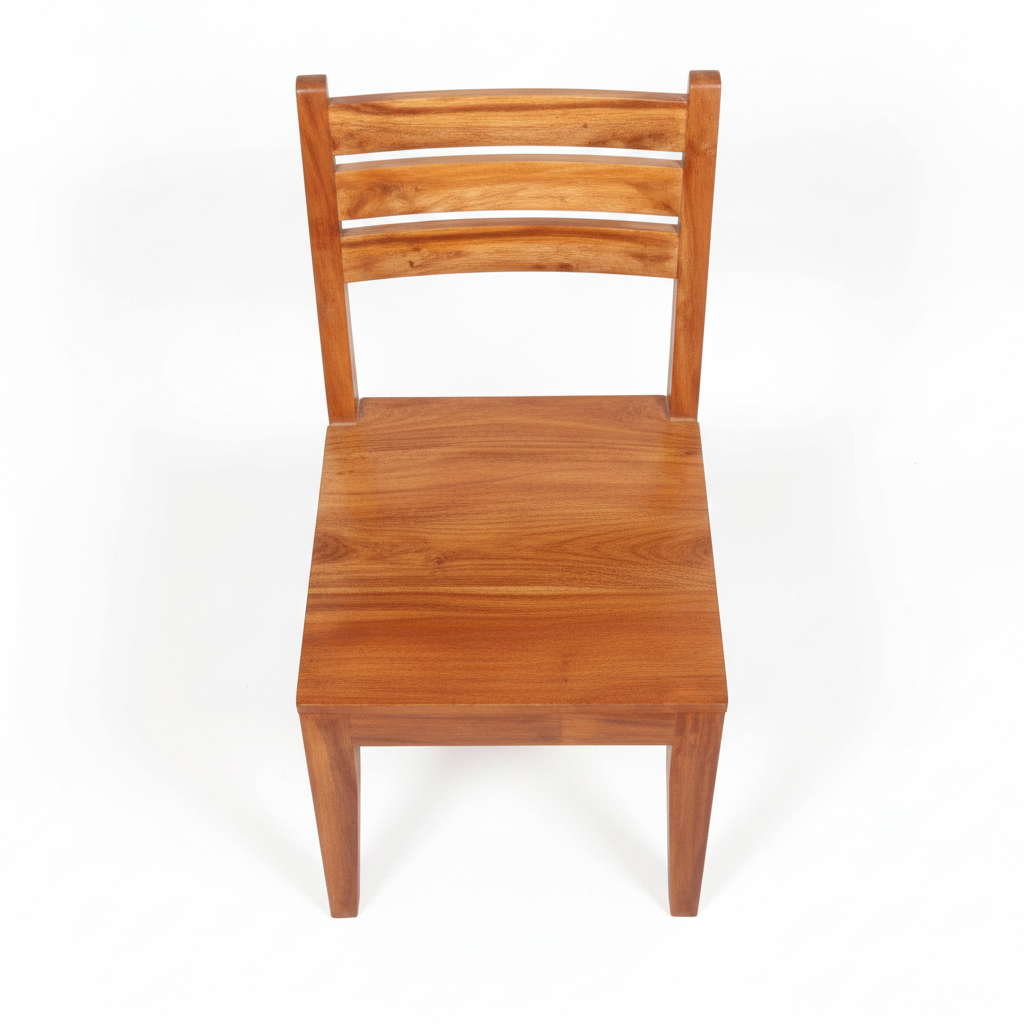

In [5]:
from PIL import Image
import os

for f in uploaded:
    os.rename(f, "input.png")

image = Image.open("input.png").convert("RGB")
image


In [6]:
latents = sample_latents(
    batch_size=1,
    model=model,
    diffusion=diffusion,
    guidance_scale=3.0,
    model_kwargs=dict(images=[image]),
    progress=True,
    device=device,

    # Required new arguments
    clip_denoised=True,
    use_fp16=torch.cuda.is_available(),
    use_karras=True,
    karras_steps=64,
    sigma_min=1e-3,
    sigma_max=160,
    s_churn=0.0,
)


  0%|          | 0/64 [00:00<?, ?it/s]

In [8]:
import trimesh
mesh = decode_latent_mesh(xm, latents[0])
print("Mesh decoded")

# Convert Shap-E mesh to trimesh
vertices = mesh.verts.detach().cpu().numpy()
faces = mesh.faces.detach().cpu().numpy()

tm = trimesh.Trimesh(vertices=vertices, faces=faces)

tm.export("generated_model.obj")

print("Mesh saved as generated_model.obj")


/content/shap-e/shap_e/models/stf/renderer.py:286: UserWarning: exception rendering with PyTorch3D: No module named 'pytorch3d'
  warnings.warn(f"exception rendering with PyTorch3D: {exc}")
/content/shap-e/shap_e/models/stf/renderer.py:287: UserWarning: falling back on native PyTorch renderer, which does not support full gradients
  warnings.warn(


Mesh decoded
Mesh saved as generated_model.obj


In [9]:
from google.colab import files
files.download("generated_model.obj")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
!git init
!git config --global user.email "selvamithra05@gmail.com"
!git config --global user.name "Selvamithra05"


Reinitialized existing Git repository in /content/shap-e/.git/


In [11]:
%%writefile .gitignore
__pycache__/
*.pyc
*.obj
*.ply
*.glb
generated_views/
shap-e/


Overwriting .gitignore


In [12]:
!git add .
!git commit -m "Initial 2D to 3D pipeline using Shap-E"


[main 8aa8a54] Initial 2D to 3D pipeline using Shap-E
 18 files changed, 211 insertions(+), 2 deletions(-)
 create mode 100644 input.png
 create mode 100644 shap_e.egg-info/PKG-INFO
 create mode 100644 shap_e.egg-info/SOURCES.txt
 create mode 100644 shap_e.egg-info/dependency_links.txt
 create mode 100644 shap_e.egg-info/requires.txt
 create mode 100644 shap_e.egg-info/top_level.txt
 create mode 100644 shap_e_model_cache/ViT-L-14.pt
 create mode 100644 shap_e_model_cache/diffusion_config.yaml
 create mode 100644 shap_e_model_cache/diffusion_config.yaml.lock
 create mode 100644 shap_e_model_cache/image_cond.pt
 create mode 100644 shap_e_model_cache/image_cond.pt.lock
 create mode 100644 shap_e_model_cache/image_cond_config.yaml
 create mode 100644 shap_e_model_cache/image_cond_config.yaml.lock
 create mode 100644 shap_e_model_cache/transmitter.pt
 create mode 100644 shap_e_model_cache/transmitter.pt.lock
 create mode 100644 shap_e_model_cache/transmitter_config.yaml
 create mode 100644 

In [15]:
%cd /content


/content


In [16]:
!mkdir 2d_3d_furniture_converter
%cd 2d_3d_furniture_converter


/content/2d_3d_furniture_converter


In [18]:
!find /content -name "*.ipynb"


/content/shap-e/shap-e/shap_e/examples/sample_text_to_3d.ipynb
/content/shap-e/shap-e/shap_e/examples/sample_image_to_3d.ipynb
/content/shap-e/shap-e/shap_e/examples/encode_model.ipynb
/content/shap-e/shap_e/examples/sample_text_to_3d.ipynb
/content/shap-e/shap_e/examples/sample_image_to_3d.ipynb
/content/shap-e/shap_e/examples/encode_model.ipynb
